# Plot $K^0\pi\pi$ reweighting
## Show the invariant mass distributions after reweighting $K^0\pi\pi$

### Turn off statistics box

In [1]:
gStyle->SetOptStat(0);

### File with MC of $K_S\pi\pi$

In [2]:
TChain Chain("KSpipiDoubleTag");
std::string Filename("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/Selection");
Filename += "/SignalMC/DoubleTag/KSpipi/KKpipi_vs_KSpipi_Binned_SignalMC_Reweighted.root";
Chain.Add(Filename.c_str());

### Loop over all bins and tags and plot $\pi\pi$ distribution

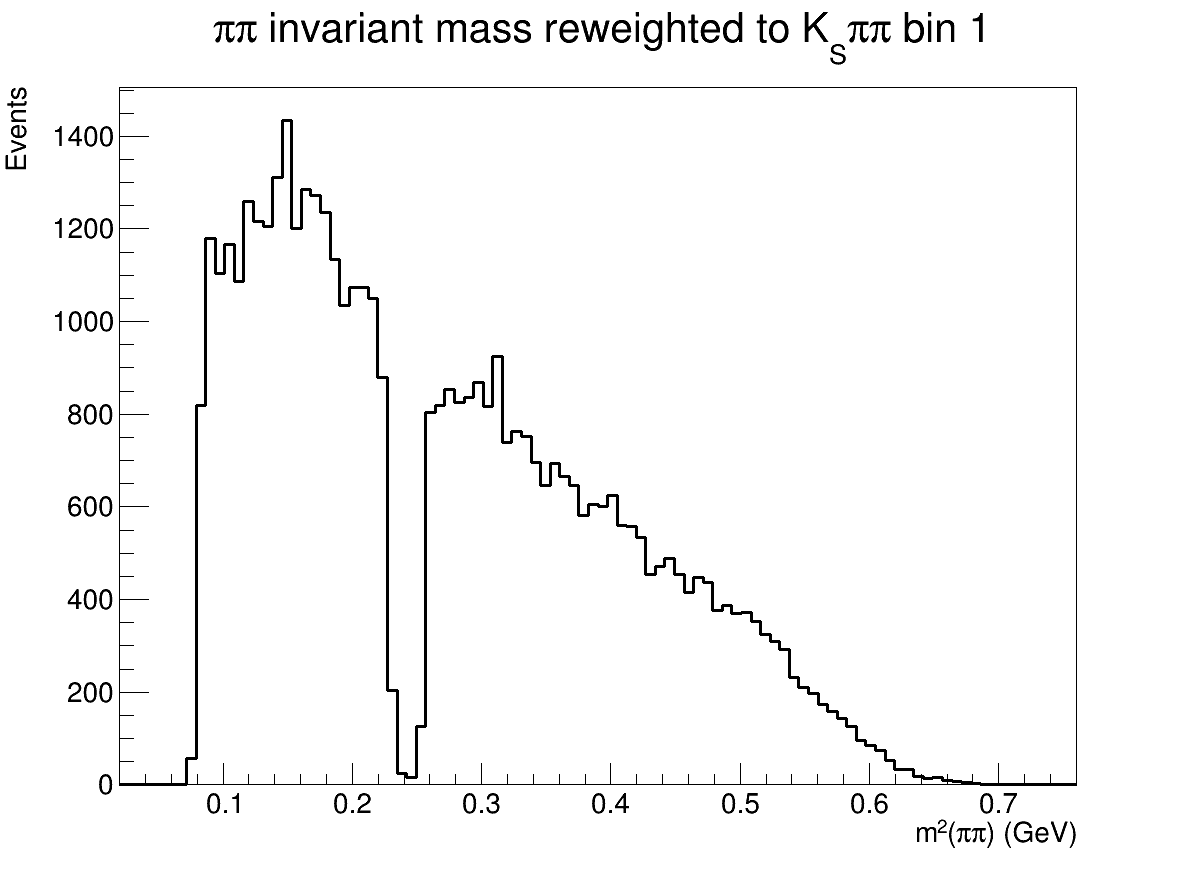

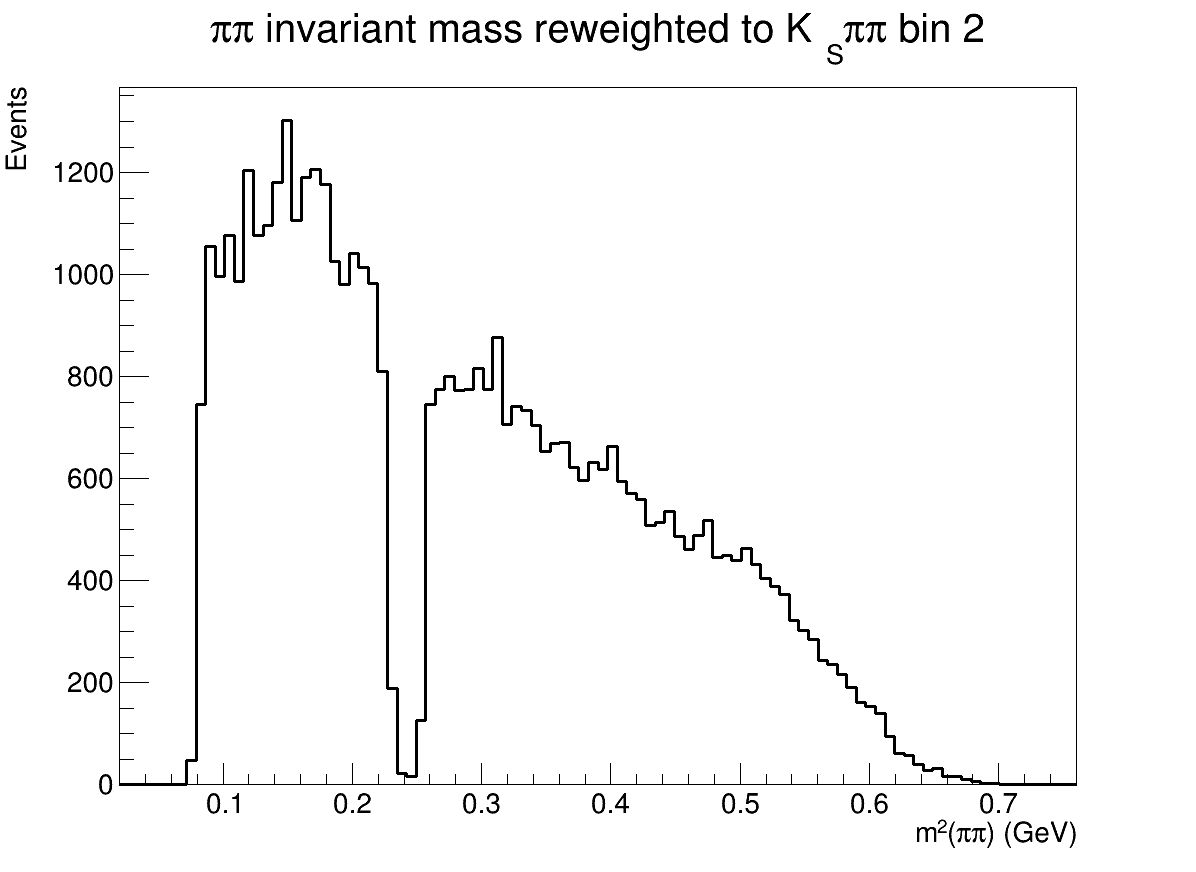

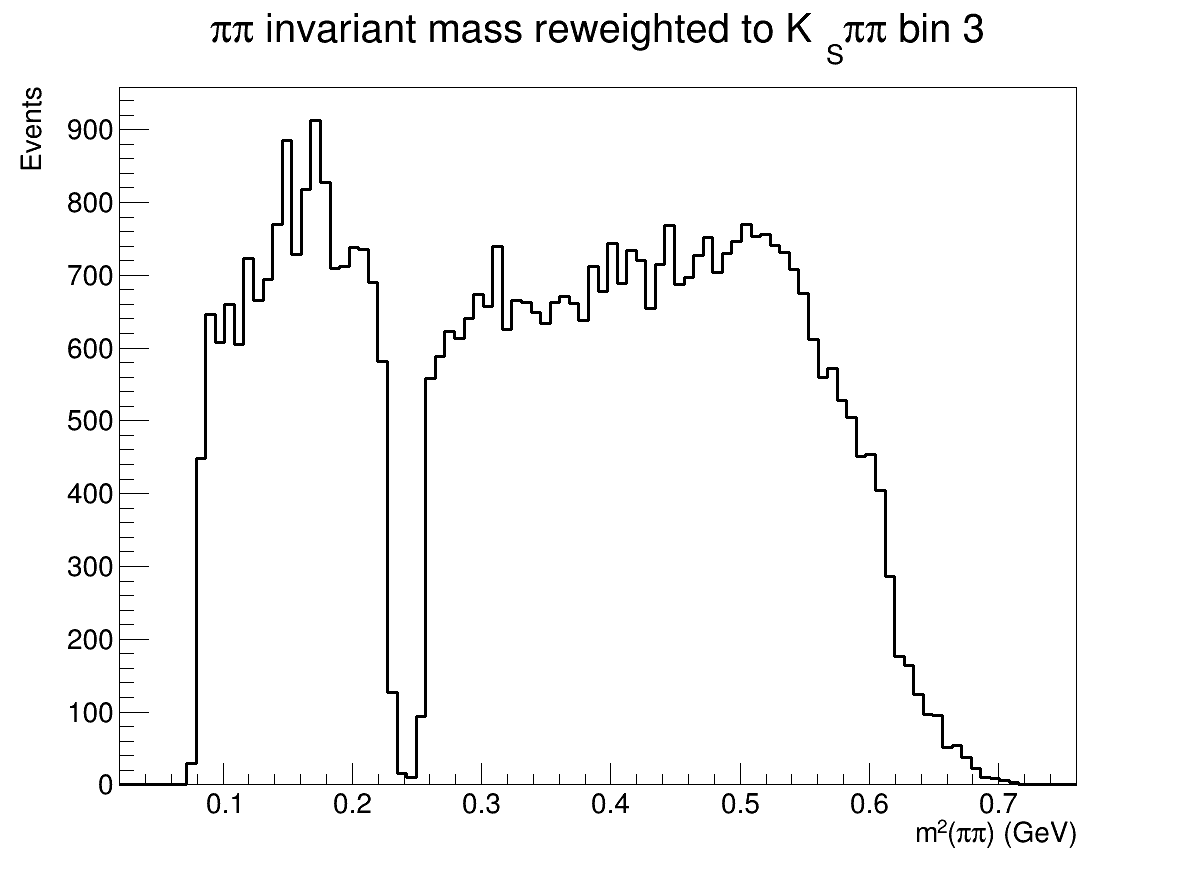

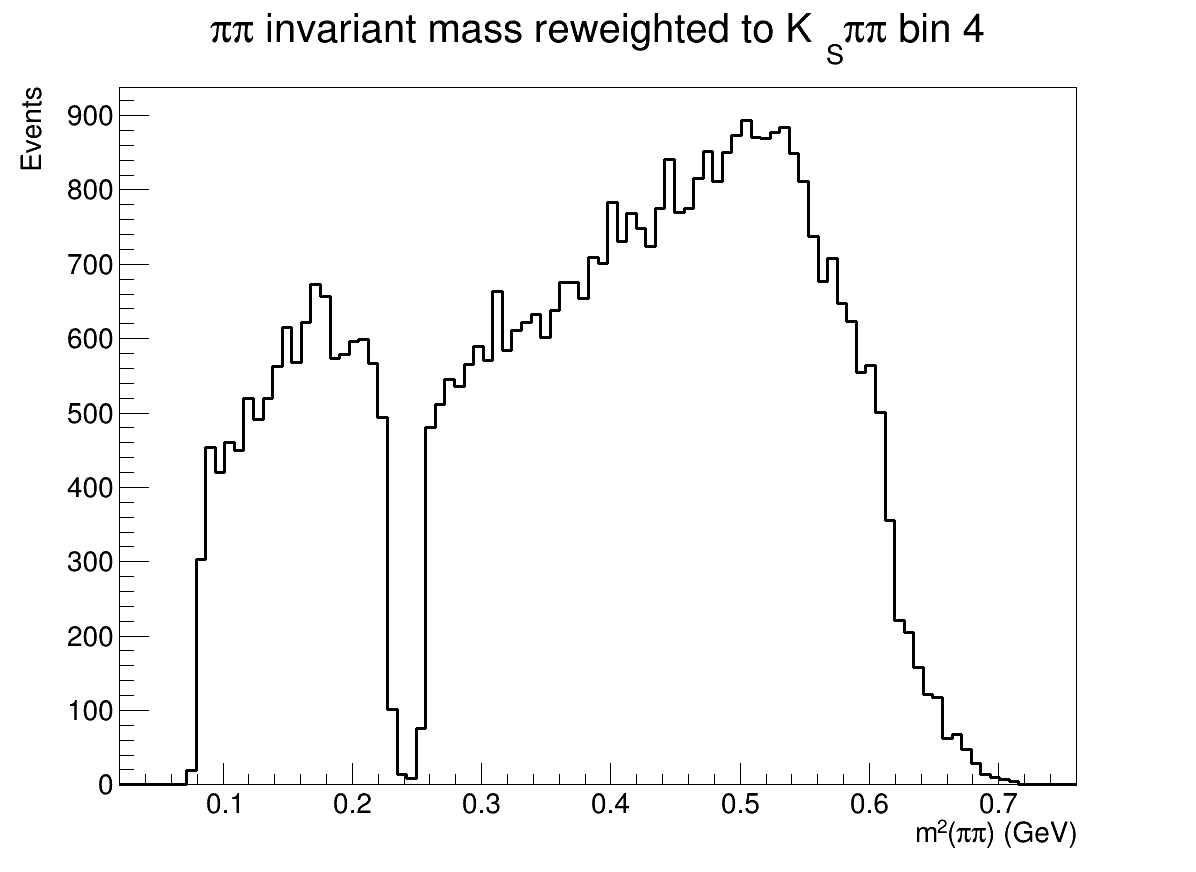

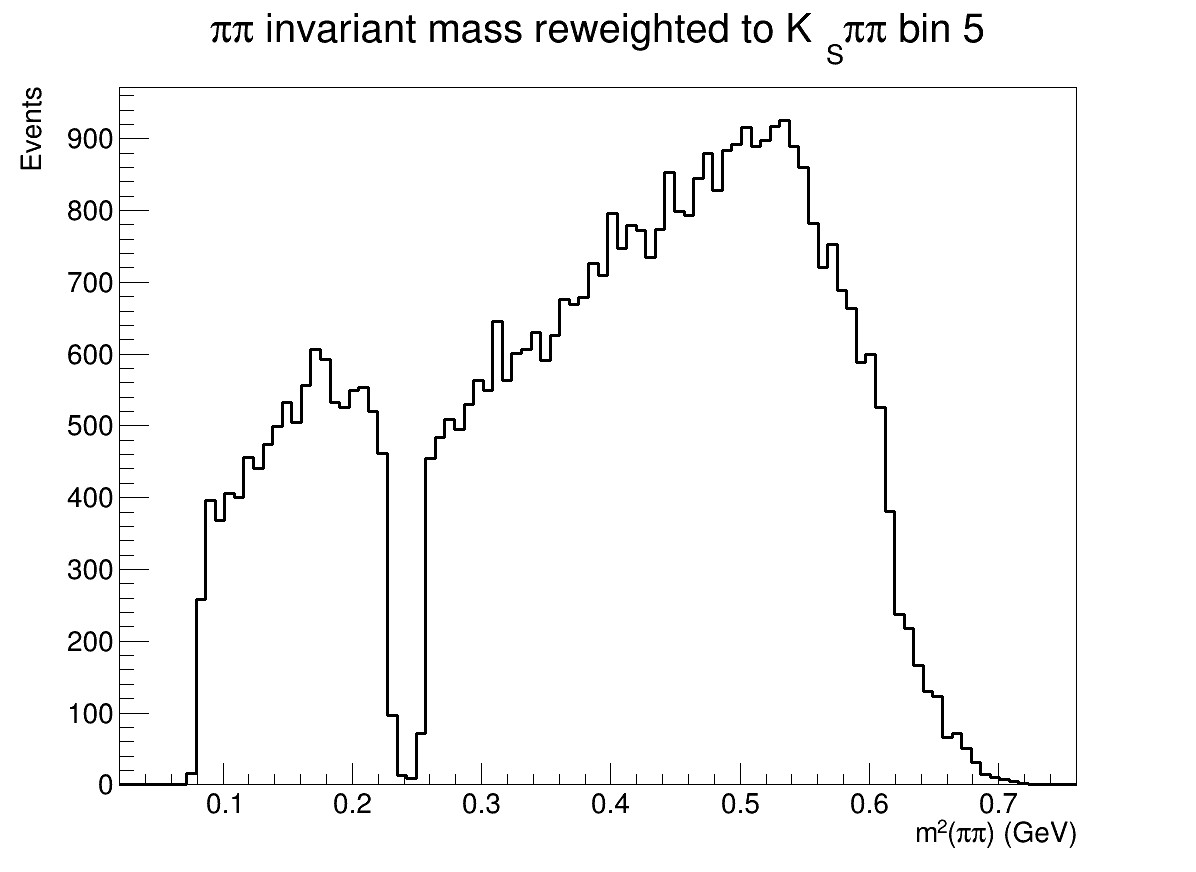

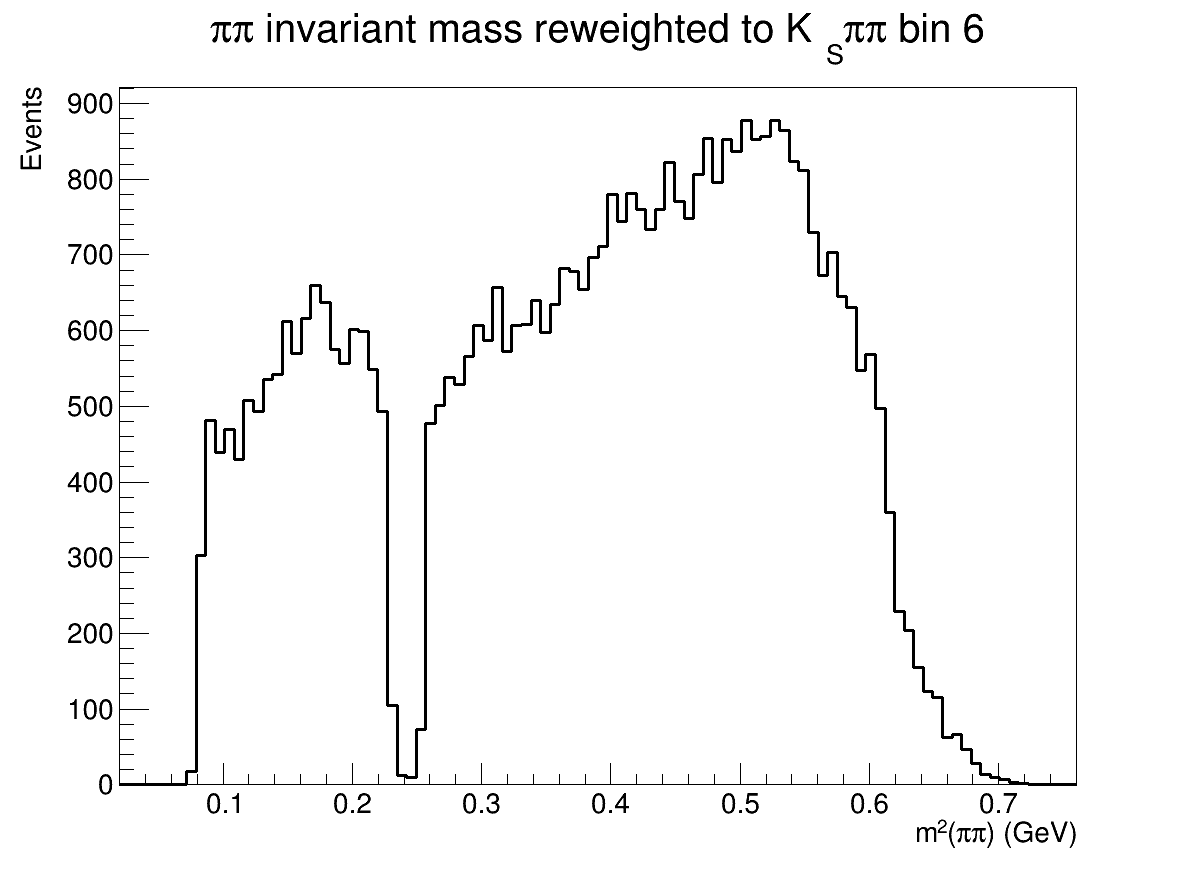

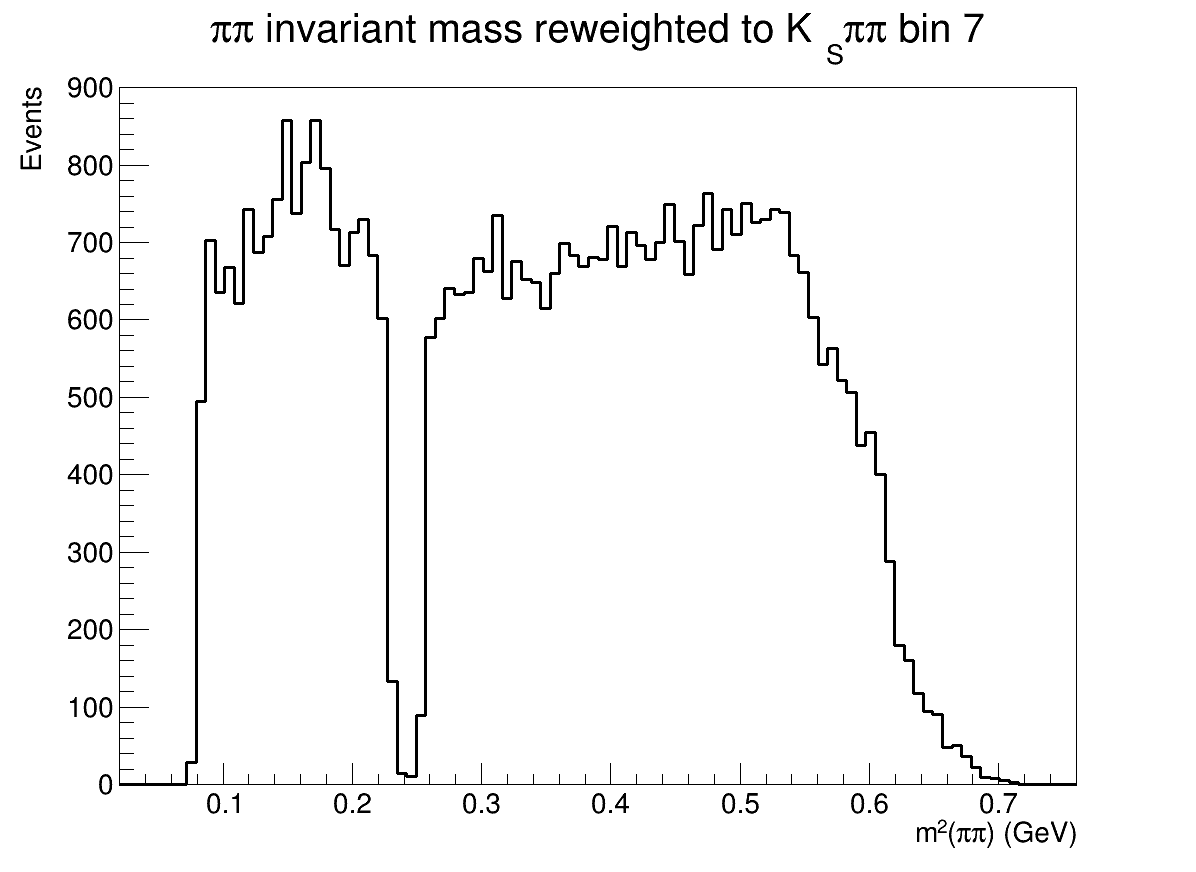

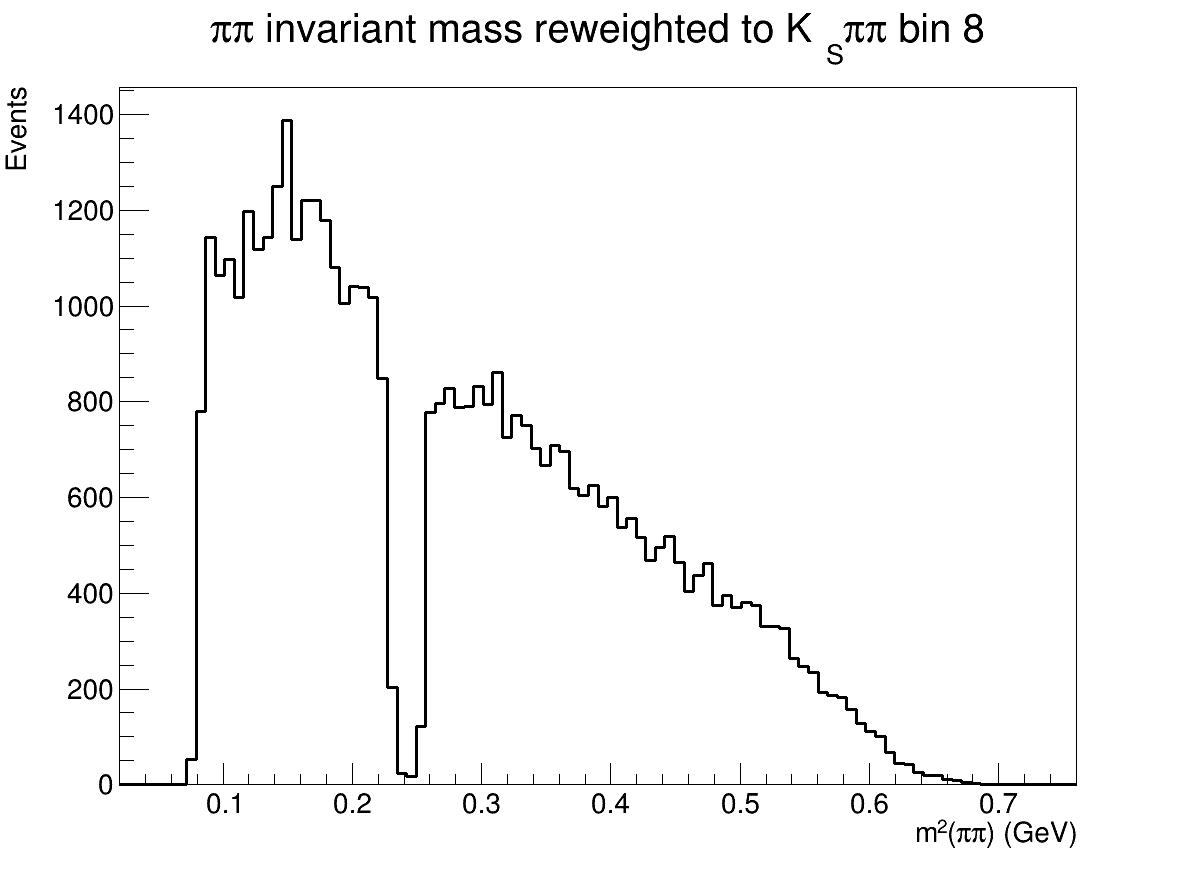

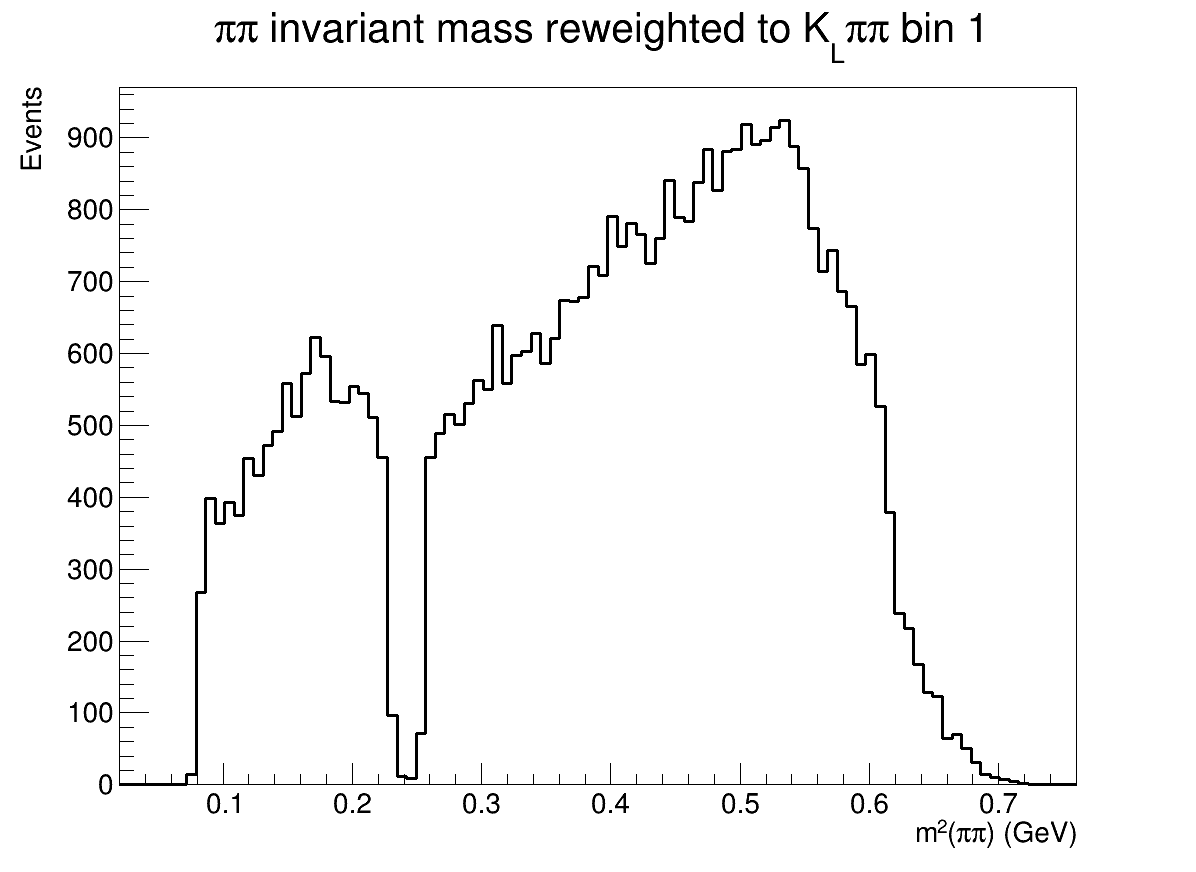

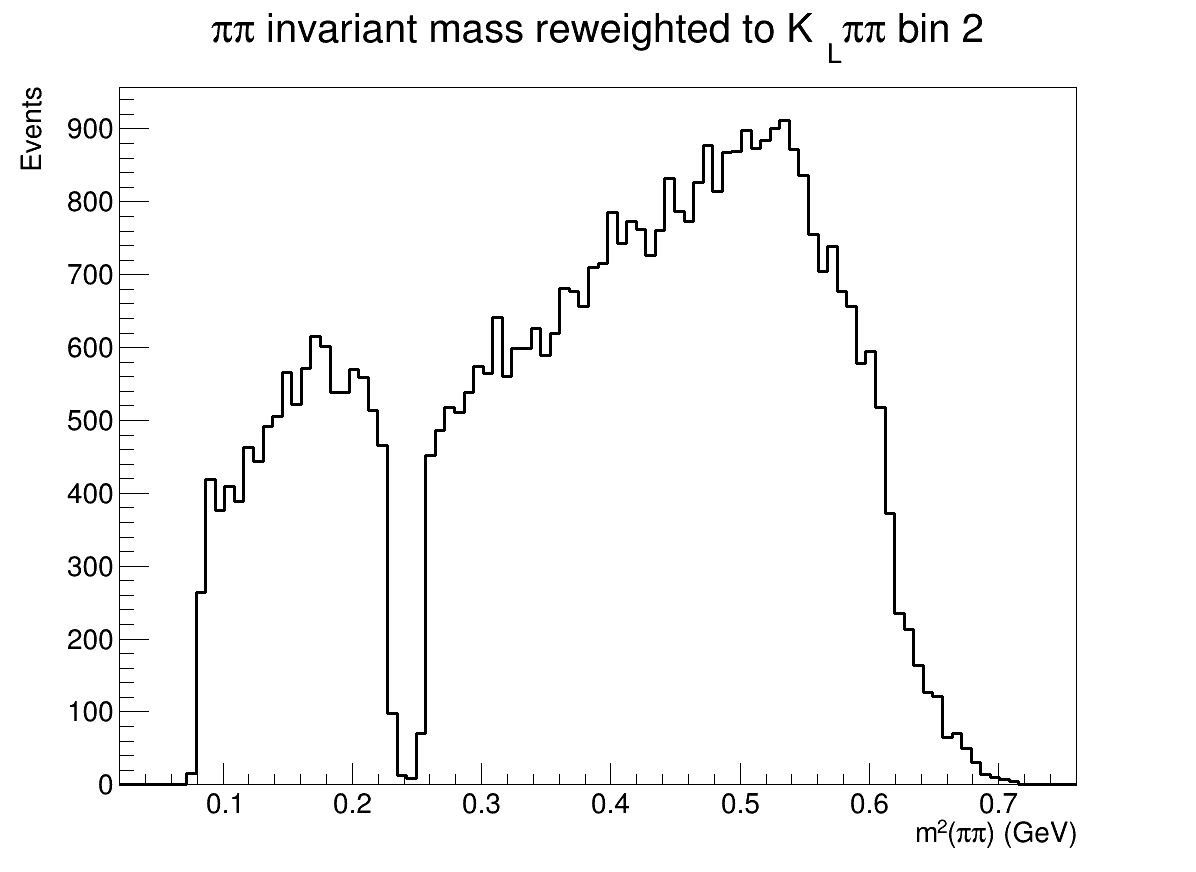

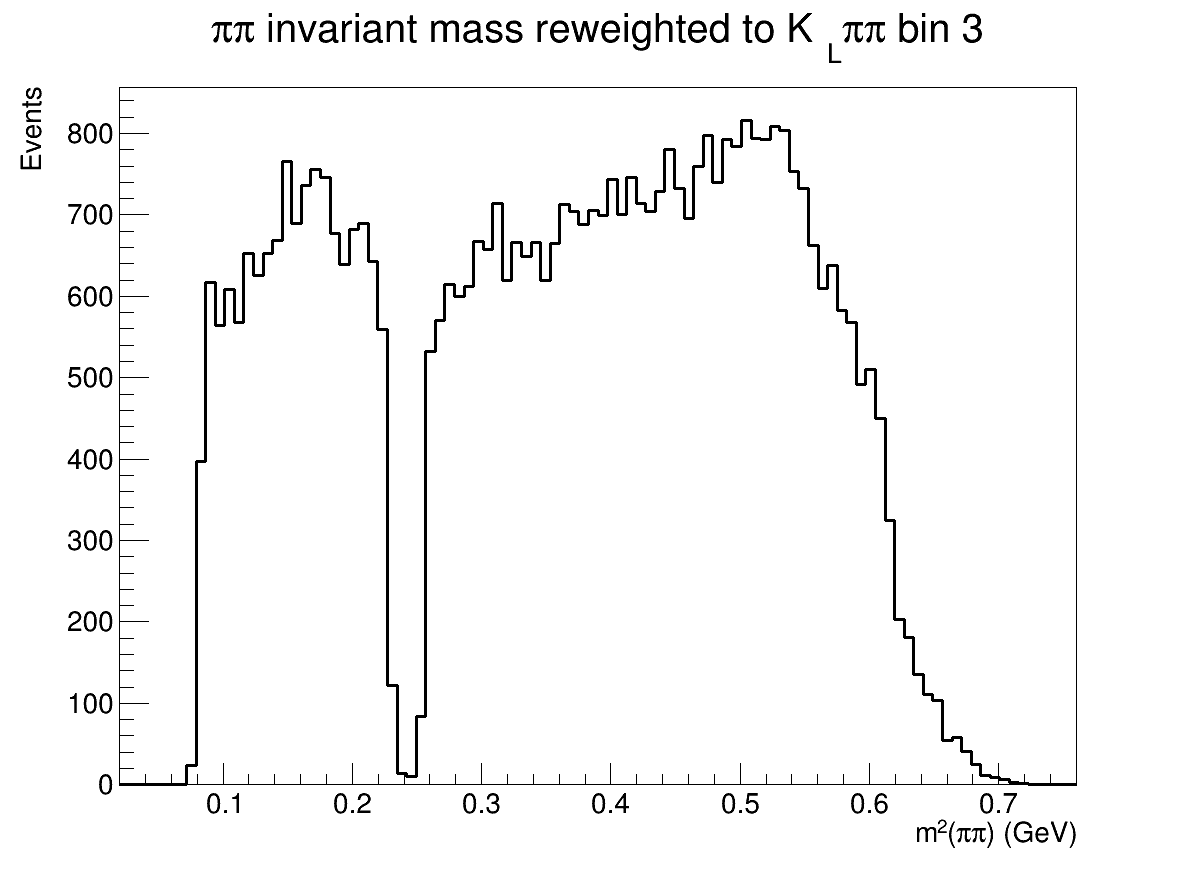

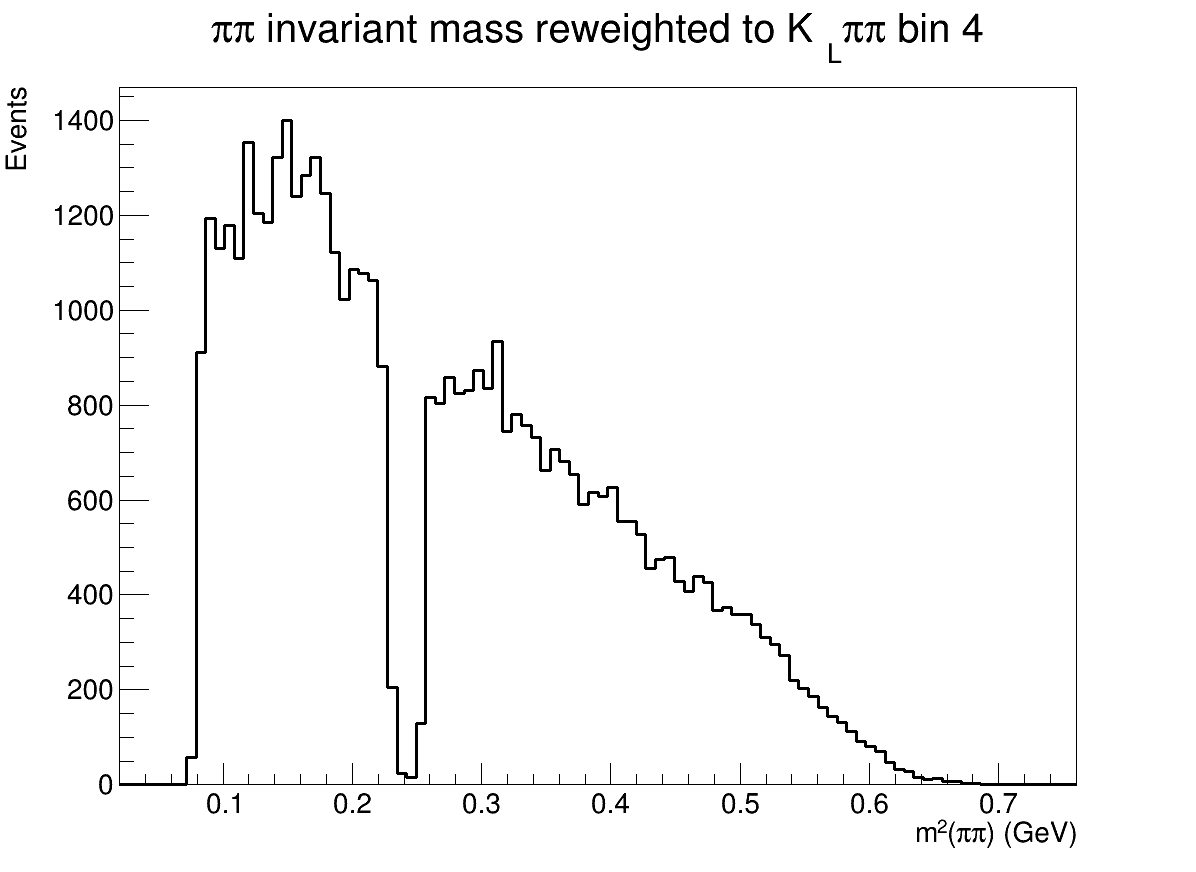

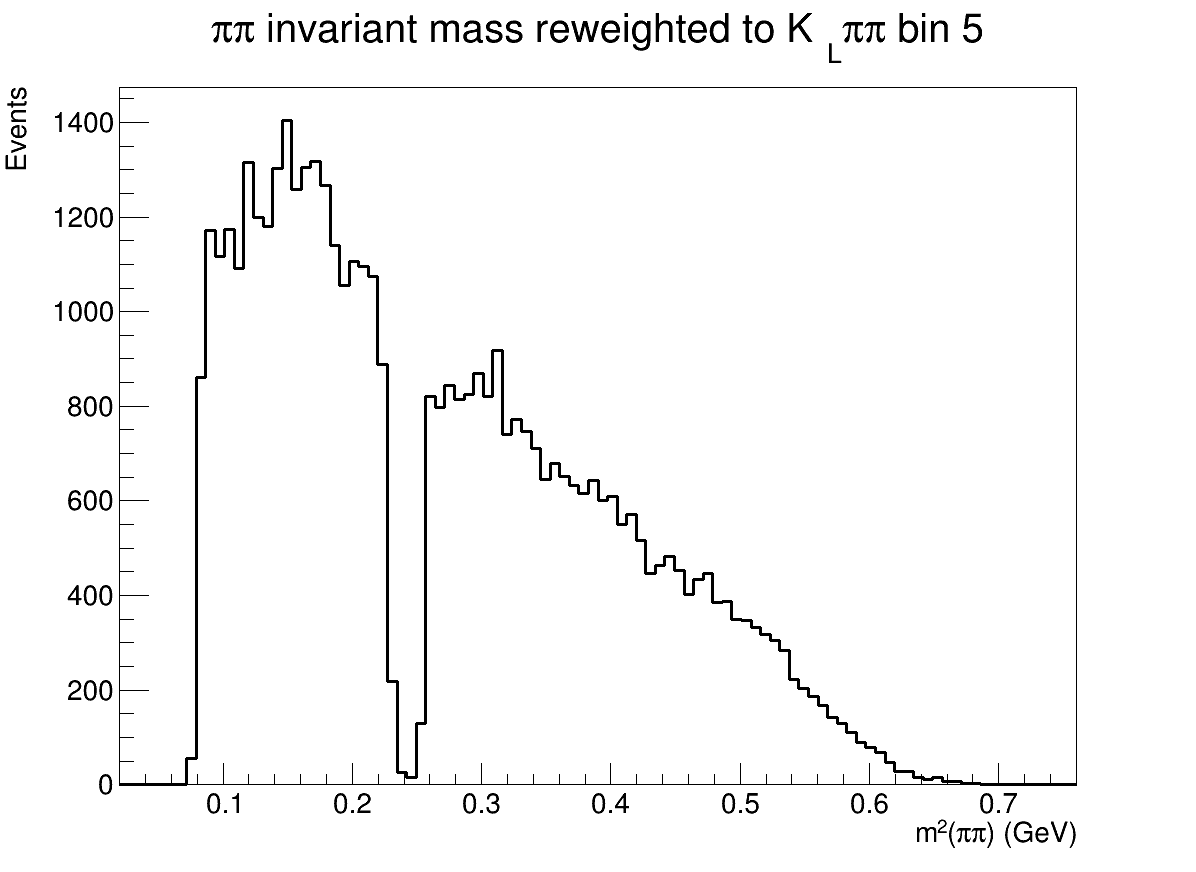

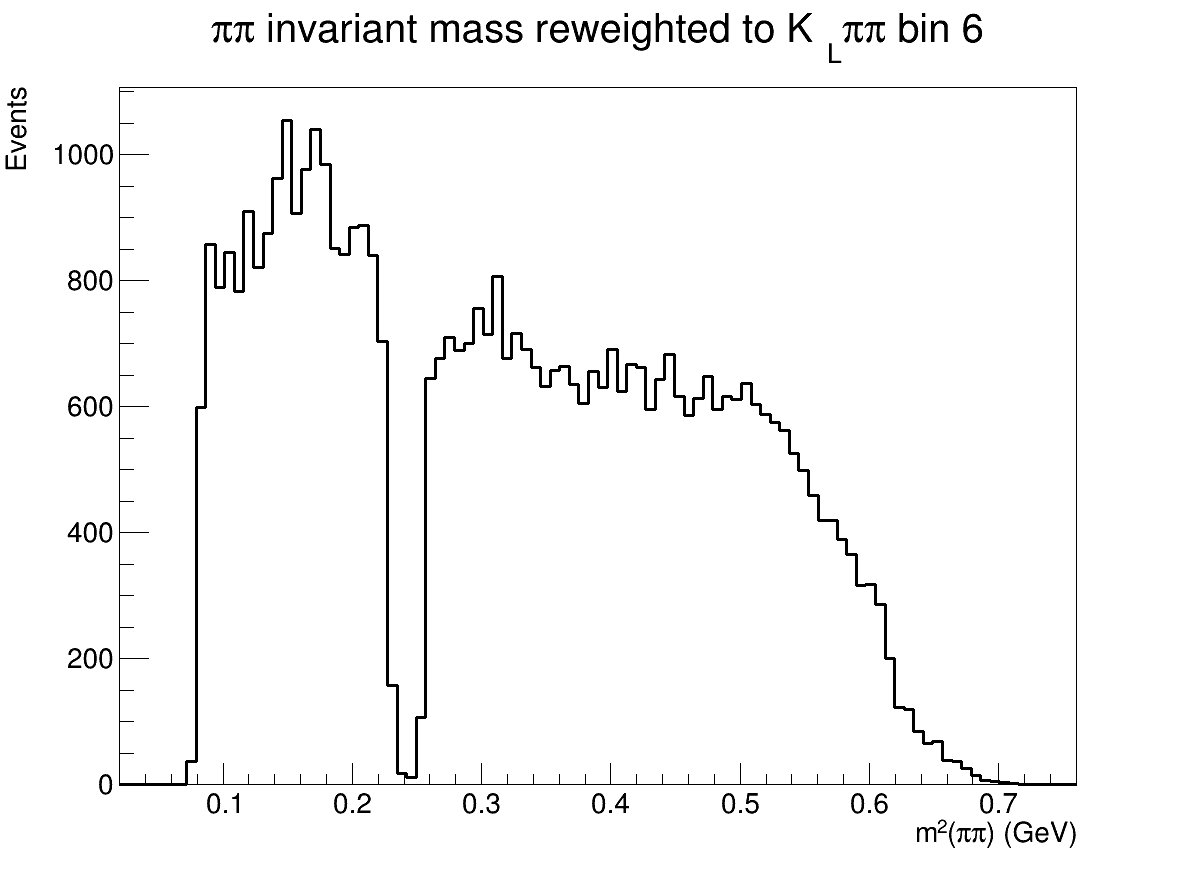

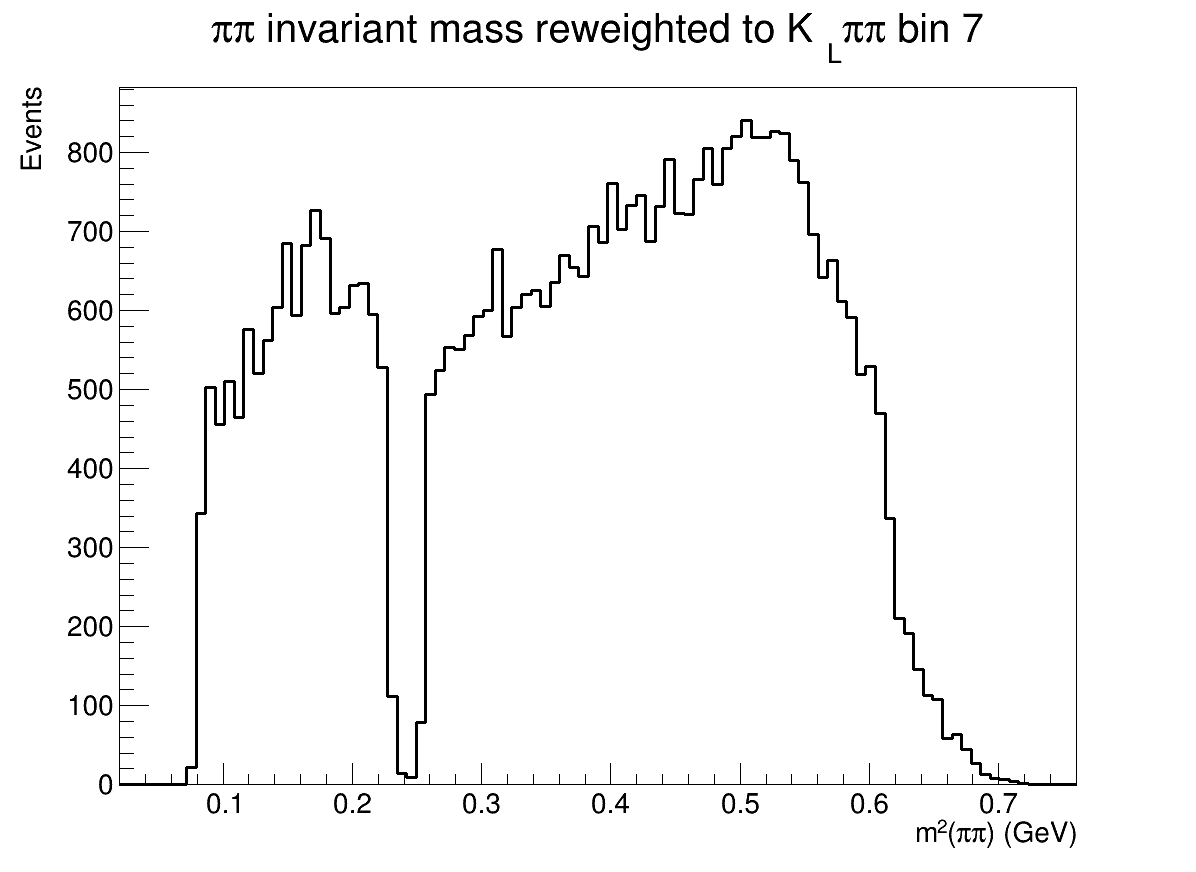

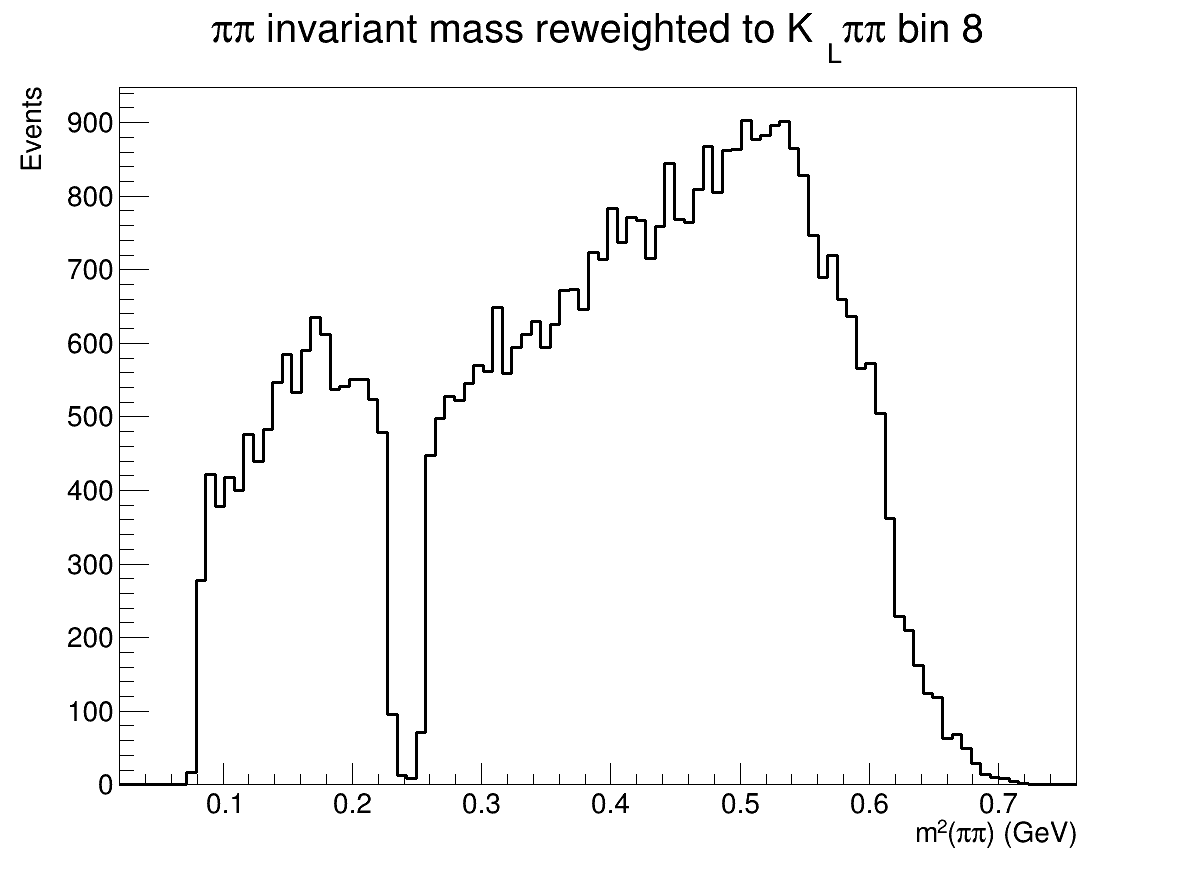

Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin1.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin2.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin3.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin4.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin5.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin6.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin7.pdf has been created
Info in <TCanvas::Print>: pdf file KSpipi_Mpipi_Reweighted_TagBin8.pdf has been created
Info in <TCanvas::Print>: pdf file KLpipi_Mpipi_Reweighted_TagBin1.pdf has been created
Info in <TCanvas::Print>: pdf file KLpipi_Mpipi_Reweighted_TagBin2.pdf has been created
Info in <TCanvas::Print>: pdf file KLpipi_Mpipi_Reweighted_TagBin3.pdf has been created
Info in <TCanvas::Print>: pdf fi

In [3]:
std::vector<std::string> Tags{"KSpipi", "KLpipi"};
for(const auto &Tag : Tags) {
    for(std::size_t i = 1; i <= 8; i++) {
        std::string Name = Tag + "_TagBin" + std::to_string(i);
        TCanvas *c = new TCanvas((Name + "_c").c_str(), "", 1200, 900);
        TH1D *h = new TH1D((Name + "_h").c_str(), "", 100, 0.0, 0.0);
        Chain.Draw(("s23 >> " + Name + "_h").c_str(), ("ModelWeight_" + Name).c_str(), "GOFF");
        h->SetLineWidth(3);
        h->SetLineColor(kBlack);
        std::string K0pipiLabel = Tag == "KSpipi" ? "K_{S}#pi#pi" : "K_{L}#pi#pi";
        std::string Title("#pi#pi invariant mass reweighted to " + K0pipiLabel + " bin " + std::to_string(i));
        Title += ";m^{2}(#pi#pi) (GeV);Events";
        h->SetTitle(Title.c_str());
        h->Draw("HIST");
        c->Draw();
        c->SaveAs((Tag + "_Mpipi_Reweighted_TagBin" + std::to_string(i) + ".pdf").c_str());
    }
}